# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 321
Columns: ['commit', 'val_bpb', 'memory_gb', 'status', 'description']


,commit,val_bpb,memory_gb,status,description
0,91904c8,2.703596,3.4,KEEP,baseline: DEPTH=8 no value embeds fp32 embeddi...
1,d6999a4,2.484215,5.2,KEEP,increase DEPTH from 8 to 10
2,2718191,2.483938,5.2,DISCARD,HEAD_DIM 128->64 (10 heads): same bpb but 3x s...
3,15d003f,2.636706,5.4,DISCARD,TOTAL_BATCH_SIZE 2^15: too few steps (18 vs 25...
4,d062f32,2.487007,2.9,DISCARD,halve batch (DEVICE=32 TOTAL=2^13): more steps...
5,d2c9dec,2.498104,5.2,DISCARD,2x LR (MATRIX=0.04 EMBED=0.2): slightly worse
6,362bfec,2.495652,9.2,DISCARD,disable torch.compile: slower per step (26s vs...
7,80ff4fb,2.479871,5.2,KEEP,shorter warmup (0.05) and warmdown (0.3) for m...
8,f6324b4,2.946762,5.2,DISCARD,no warmup (0.0) warmdown (0.2): destabilized t...
9,8ec56ea,2.469410,5.2,KEEP,replace relu().square() with GELU activation


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    245
KEEP        63
CRASH       13

Keep rate: 63/308 = 20.5%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (63 total):

  #  0  bpb=2.703596  mem=3.4GB  baseline: DEPTH=8 no value embeds fp32 embeddings Muon optimizer
  #  1  bpb=2.484215  mem=5.2GB  increase DEPTH from 8 to 10
  #  7  bpb=2.479871  mem=5.2GB  shorter warmup (0.05) and warmdown (0.3) for more steps at peak LR
  #  9  bpb=2.469410  mem=5.2GB  replace relu().square() with GELU activation
  # 14  bpb=2.423363  mem=5.2GB  softcap 15->30: significant improvement (2.423 vs 2.469)
  # 15  bpb=2.416217  mem=5.2GB  remove logit softcap: simpler code and better (2.416 vs 2.423)
  # 19  bpb=2.389136  mem=5.2GB  EMBEDDING_LR 0.1->0.2: good improvement (2.389 vs 2.416)
  # 20  bpb=2.377585  mem=5.2GB  EMBEDDING_LR 0.2->0.3: another improvement (2.378 vs 2.389)
  # 21  bpb=2.367744  mem=5.2GB  EMBEDDING_LR 0.3->0.5: still improving (2.368 vs 2.378)
  # 22  bpb=2.367144  mem=5.2GB  EMBEDDING_LR 0.5->0.8: marginal (2.367 vs 2.368)
  # 23  bpb=2.363770  mem=5.2GB  UNEMBEDDING_LR 0.004->0.008: improvement (2.364 vs 2.367)
  

## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

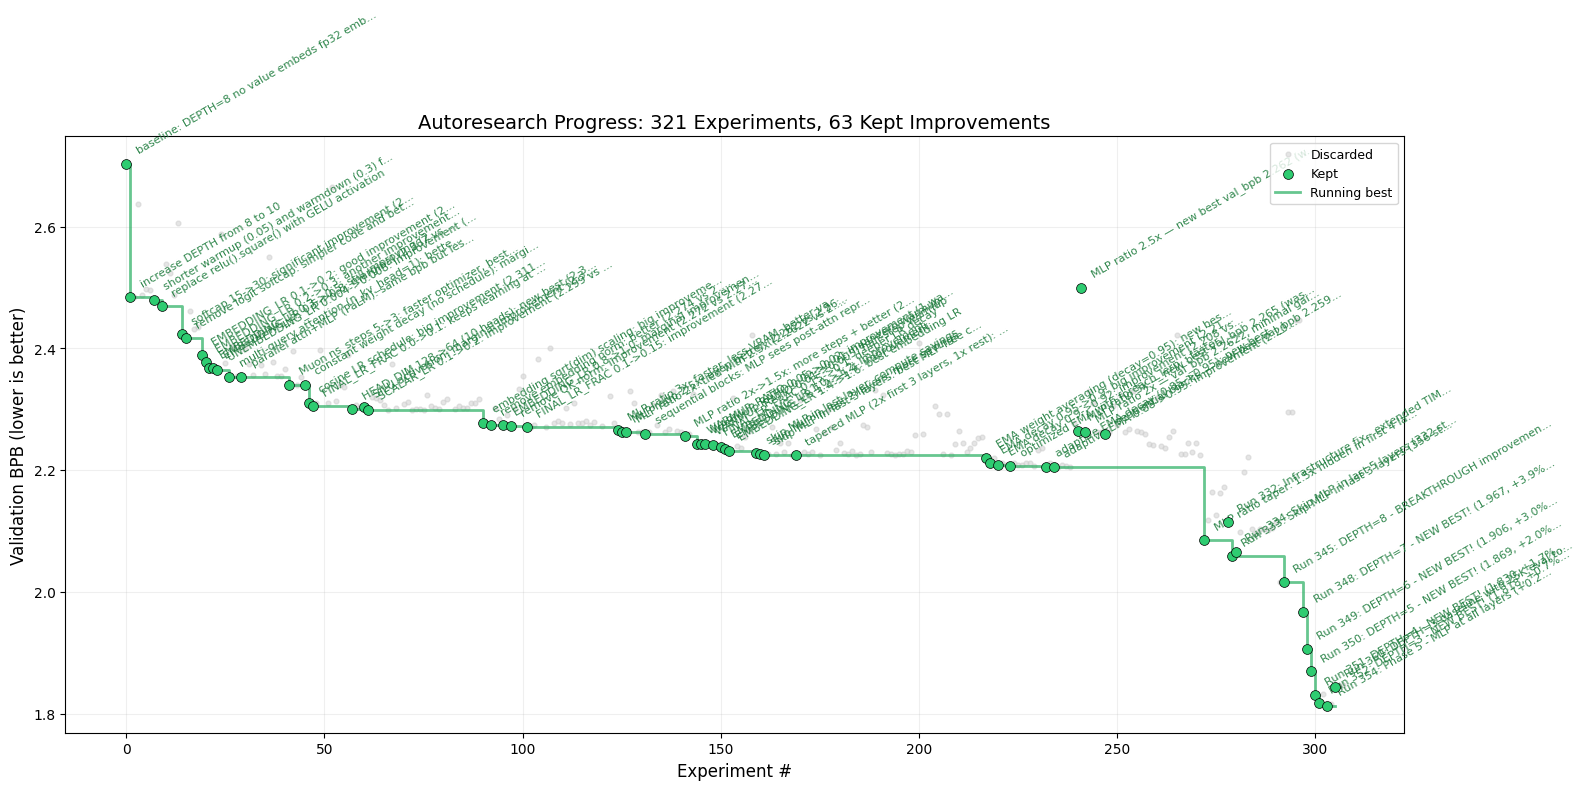

Saved to progress.png


In [6]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_bpb"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_bpb"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
best = kept_v["val_bpb"].min()
margin = max(0.02, 0.05 * (baseline_bpb - best))
ax.set_ylim(best - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [ ]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

## Top Hits (Kept Experiments by Improvement)

In [ ]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")